# Multi-Step Workflow with Conditional Routing

This notebook extends the basic ReAct pattern with **LLM-based classification** and **specialized sub-agents**. Instead of a single agent that handles all queries, we build a workflow that:

1. **Classifies** the incoming query using the LLM (math, weather, or general)
2. **Routes** to a specialized agent node that only has access to relevant tools
3. **Executes** the tool-calling loop within the specialized agent

This pattern is useful in production when you want to:
- Limit tool access per domain for safety and cost
- Use different system prompts per domain for better accuracy
- Add domain-specific pre/post-processing

**Graph topology:**
```
                    START
                      |
                 [classifier]
                      |
              route_by_category
               /      |      \
       math_agent  weather_agent  general_agent
              \      |      /
            check_tool_calls
              /            \
        has tool calls    no tool calls
             |                |
          [tools]            END
             |
       route_back_to_agent  (loops back to the originating agent)
```

## Import Libraries and Load Environment

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Initialize the LLM and Tools

Same setup as the basic ReAct notebook -- `ChatOpenAI` proxy with `@tool`-decorated functions.

In [2]:
from gen_ai_hub.proxy.langchain.openai import ChatOpenAI
from langchain_core.tools import tool
from tools import add as _add, multiply as _multiply, get_weather as _get_weather

llm = ChatOpenAI(
    proxy_model_name="gpt-4.1",
    temperature=0.0,
    max_tokens=1024,
)


@tool
def add(a: float, b: float) -> float:
    """Add two numbers together. Use this for addition operations."""
    return _add(a, b)


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers together. Use this for multiplication operations."""
    return _multiply(a, b)


@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city (mock implementation for demonstration)."""
    return _get_weather(city)


math_tools = [add, multiply]
weather_tools = [get_weather]
all_tools = [add, multiply, get_weather]

print(f"Math tools: {[t.name for t in math_tools]}")
print(f"Weather tools: {[t.name for t in weather_tools]}")
print(f"All tools: {[t.name for t in all_tools]}")

Math tools: ['add', 'multiply']
Weather tools: ['get_weather']
All tools: ['add', 'multiply', 'get_weather']


## Define the Custom State

We extend the standard `MessagesState` with a `category` field. The classifier node sets this field, and the routing function reads it to decide which agent to invoke.

The `Annotated[list, add_messages]` type tells LangGraph to use the `add_messages` reducer, which appends new messages to the existing list rather than replacing it.

In [3]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


class WorkflowState(TypedDict):
    messages: Annotated[list, add_messages]
    category: str

## Define the Classifier Node

The classifier uses the LLM itself to categorize the user's query into one of three categories: `math`, `weather`, or `general`. This is more robust than keyword matching because the LLM understands intent and context.

The classifier's output is a single word stored in the `category` field of the state.

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

CLASSIFIER_PROMPT = """Classify the following user query into exactly one category.

Categories:
- "math": Questions involving arithmetic, calculations, or numbers
- "weather": Questions about weather conditions in any city
- "general": Questions that involve both math and weather, or neither

Respond with ONLY the category name (math, weather, or general). No explanation."""


def classifier_node(state: WorkflowState):
    """Classify the user's query into a category."""
    user_message = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content=CLASSIFIER_PROMPT),
        HumanMessage(content=user_message),
    ])
    category = response.content.strip().lower()

    # Normalize to valid categories
    if category not in ("math", "weather", "general"):
        category = "general"

    print(f"[Classifier] Query: '{user_message}' -> Category: '{category}'")
    return {"category": category}

## Define Specialized Agent Nodes

Each agent node binds only its relevant tools to the LLM and uses a domain-specific system prompt. This means:
- The math agent can only call `add` and `multiply`
- The weather agent can only call `get_weather`
- The general agent has access to all tools

In [5]:
math_llm = llm.bind_tools(math_tools)
weather_llm = llm.bind_tools(weather_tools)
general_llm = llm.bind_tools(all_tools)


def math_agent(state: WorkflowState):
    """Handle math queries with access to add and multiply tools."""
    system = SystemMessage(
        content="You are a math assistant. Use the add and multiply tools to solve calculations. "
        "Always use tools for arithmetic -- do not compute in your head."
    )
    response = math_llm.invoke([system] + state["messages"])
    return {"messages": [response]}


def weather_agent(state: WorkflowState):
    """Handle weather queries with access to the get_weather tool."""
    system = SystemMessage(
        content="You are a weather assistant. Use the get_weather tool to look up weather conditions. "
        "Always use the tool -- do not guess weather information."
    )
    response = weather_llm.invoke([system] + state["messages"])
    return {"messages": [response]}


def general_agent(state: WorkflowState):
    """Handle general or combined queries with access to all tools."""
    system = SystemMessage(
        content="You are a helpful assistant with access to math and weather tools. "
        "Use the appropriate tools to answer the user's question."
    )
    response = general_llm.invoke([system] + state["messages"])
    return {"messages": [response]}

## Build the Workflow Graph

The graph has four main components:

1. **Classifier node** -- categorizes the query
2. **Routing function** (`route_by_category`) -- reads the category and sends to the right agent
3. **Agent nodes** -- each with their own tool bindings
4. **Tool node** -- shared `ToolNode` that executes tool calls from any agent
5. **Tool result routing** (`check_tool_calls`, `route_back_to_agent`) -- after tool execution, routes back to the correct agent based on the category

In [6]:
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode


def route_by_category(state: WorkflowState) -> str:
    """Route to the specialized agent based on the classified category."""
    category = state.get("category", "general")
    return {"math": "math_agent", "weather": "weather_agent"}.get(category, "general_agent")


def check_tool_calls(state: WorkflowState) -> str:
    """Check if the last message has tool calls. If yes, go to tools; otherwise, END."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


def route_back_to_agent(state: WorkflowState) -> str:
    """After tool execution, route back to the same agent that initiated the call."""
    category = state.get("category", "general")
    return {"math": "math_agent", "weather": "weather_agent"}.get(category, "general_agent")


# Build the graph
workflow = StateGraph(WorkflowState)

# Add nodes
workflow.add_node("classifier", classifier_node)
workflow.add_node("math_agent", math_agent)
workflow.add_node("weather_agent", weather_agent)
workflow.add_node("general_agent", general_agent)
workflow.add_node("tools", ToolNode(tools=all_tools))

# Entry point
workflow.add_edge(START, "classifier")

# Classifier routes to the right agent
workflow.add_conditional_edges(
    "classifier",
    route_by_category,
    {"math_agent": "math_agent", "weather_agent": "weather_agent", "general_agent": "general_agent"},
)

# Each agent either calls tools or finishes
for agent_name in ["math_agent", "weather_agent", "general_agent"]:
    workflow.add_conditional_edges(
        agent_name,
        check_tool_calls,
        {"tools": "tools", END: END},
    )

# Tools route back to the originating agent
workflow.add_conditional_edges(
    "tools",
    route_back_to_agent,
    {"math_agent": "math_agent", "weather_agent": "weather_agent", "general_agent": "general_agent"},
)

multi_step_agent = workflow.compile()

print("Multi-step workflow compiled successfully.")

Multi-step workflow compiled successfully.


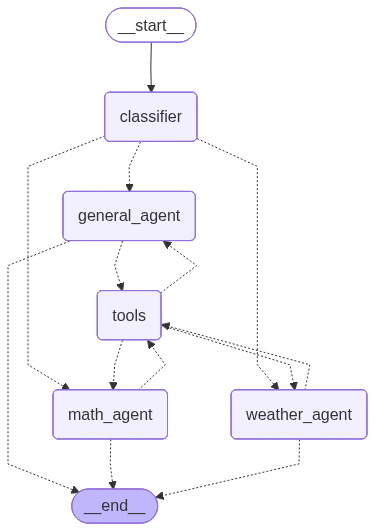

In [7]:
# Visualize the graph structure
from IPython.display import Image, display

display(Image(multi_step_agent.get_graph().draw_mermaid_png()))

## Run the Workflow

Let's test with three types of queries to see the routing in action.

In [8]:
def print_workflow_trace(result: dict) -> None:
    """Print the full message and routing trace from a workflow invocation."""
    print(f"Category: {result.get('category', 'unknown')}")
    print("---")
    for msg in result["messages"]:
        role = msg.__class__.__name__
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            tool_calls_str = ", ".join(
                f"{tc['name']}({tc['args']})" for tc in msg.tool_calls
            )
            print(f"[{role}] Tool calls: {tool_calls_str}")
        elif hasattr(msg, "content") and msg.content:
            print(f"[{role}] {msg.content}")
    print()

In [9]:
# Example 1: Math query (routed to math_agent)
print("=" * 60)
print("Query: What is 12 + 8, and then multiply the result by 3?")
print("=" * 60)

result = multi_step_agent.invoke({
    "messages": [HumanMessage(content="What is 12 + 8, and then multiply the result by 3?")]
})
print_workflow_trace(result)

Query: What is 12 + 8, and then multiply the result by 3?
[Classifier] Query: 'What is 12 + 8, and then multiply the result by 3?' -> Category: 'math'
Category: math
---
[HumanMessage] What is 12 + 8, and then multiply the result by 3?
[AIMessage] Tool calls: add({'a': 12, 'b': 8})
[ToolMessage] 20.0
[AIMessage] Tool calls: multiply({'a': 20, 'b': 3})
[ToolMessage] 60.0
[AIMessage] 12 + 8 is 20, and multiplying the result by 3 gives 60.



In [10]:
# Example 2: Weather query (routed to weather_agent)
print("=" * 60)
print("Query: What is the weather like in Tokyo?")
print("=" * 60)

result = multi_step_agent.invoke({
    "messages": [HumanMessage(content="What is the weather like in Tokyo?")]
})
print_workflow_trace(result)

Query: What is the weather like in Tokyo?
[Classifier] Query: 'What is the weather like in Tokyo?' -> Category: 'weather'
Category: weather
---
[HumanMessage] What is the weather like in Tokyo?
[AIMessage] Tool calls: get_weather({'city': 'Tokyo'})
[ToolMessage] Rainy, 18 degrees Celsius
[AIMessage] The weather in Tokyo is currently rainy with a temperature of 18°C.



In [11]:
# Example 3: Combined query (routed to general_agent)
print("=" * 60)
print("Query: What is the weather in Berlin, and also calculate 25 + 17?")
print("=" * 60)

result = multi_step_agent.invoke({
    "messages": [HumanMessage(content="What is the weather in Berlin, and also calculate 25 + 17?")]
})
print_workflow_trace(result)

Query: What is the weather in Berlin, and also calculate 25 + 17?
[Classifier] Query: 'What is the weather in Berlin, and also calculate 25 + 17?' -> Category: 'general'
Category: general
---
[HumanMessage] What is the weather in Berlin, and also calculate 25 + 17?
[AIMessage] Tool calls: get_weather({'city': 'Berlin'}), add({'a': 25, 'b': 17})
[ToolMessage] Cloudy, 8 degrees Celsius
[ToolMessage] 42.0
[AIMessage] The weather in Berlin is cloudy with a temperature of 8°C. Also, 25 + 17 equals 42.



## Summary

This notebook demonstrated **conditional routing with specialized sub-agents**, a pattern that goes beyond basic ReAct.

**Comparison of patterns:**

| Aspect | Basic ReAct (Notebook 01) | Multi-Step Workflow (This Notebook) |
|--------|--------------------------|------------------------------------|
| Routing | Single agent handles all queries | LLM classifier routes to specialists |
| Tool access | All tools available to one agent | Tools scoped per domain |
| State | `MessagesState` only | Custom state with `category` field |
| System prompt | One generic prompt | Domain-specific prompts per agent |
| Use case | General-purpose tool use | Domain-specific, production workflows |

**When to use which:**
- Use **basic ReAct** when you have a small number of tools and simple queries
- Use **conditional routing** when you need domain isolation, different prompts per domain, or when tool count grows large enough that a single agent becomes unreliable